In [10]:
import tensorflow as tf
import os

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATASET_DIR = "D:/Senior_WorkTable/GrowQuest_Data_Final"


In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "val"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=False
)


Found 4199 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.


In [12]:
# Normalize (0-1)
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Pro-level data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.GaussianNoise(0.05)
])

def augment(image, label):
    return data_augmentation(image), label


In [13]:
train_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)


In [14]:
tf.random.set_seed(42)

In [15]:
# Save class names early
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = raw_train_ds.class_names
print(class_names)

# Then continue building with .map(), .repeat(), etc. using raw_train_ds



Found 4199 files belonging to 3 classes.
['Anthracnose', 'Healthy_Leaf', 'Pest_Damage']


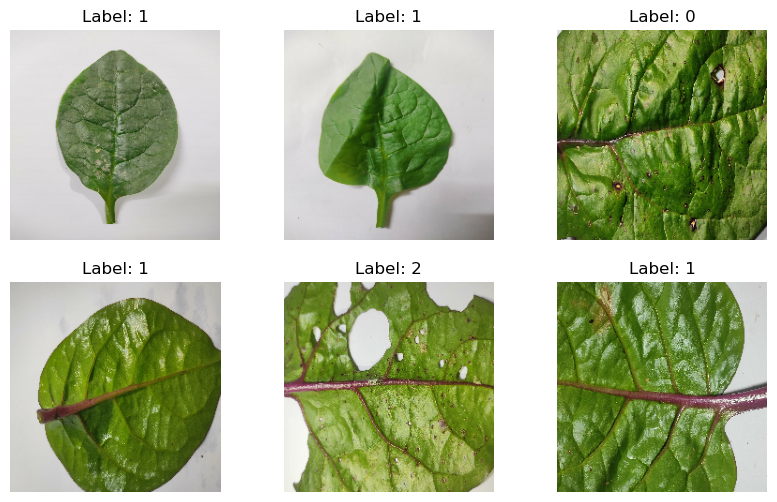

In [16]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 6))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {tf.argmax(labels[i]).numpy()}")
        plt.axis("off")


About to Training

In [17]:
from tensorflow.keras import layers, models, Input

def build_custom_classifier(base_model, input_shape=(224, 224, 3), num_classes=3, dropout_rate=0.3):
    inputs = Input(shape=input_shape, name="input_image")
    x = base_model(inputs, training=False)  # keeps batchnorm frozen

    # Optional: Add a Conv layer to squeeze spatial features before GAP
    x = layers.Conv2D(64, (1, 1), activation='relu', name="bottleneck_conv")(x)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="batch_norm")(x)
    x = layers.Dense(128, activation='relu', name="dense_relu")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="classifier")(x)

    return models.Model(inputs, outputs, name="PlantClassifierModel")


In [18]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models, Input

def build_mobilenetv3_base(input_shape=(224, 224, 3), trainable=False):
    base_model = MobileNetV3Large(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = trainable  # Set True only during fine-tuning
    return base_model

# Build the base model first
base_model = build_mobilenetv3_base(input_shape=(224, 224, 3), trainable=True)

# Then pass it to your classifier
model = build_custom_classifier(base_model, input_shape=(224, 224, 3), num_classes=3)




In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# 🎯 Learning Rate Scheduler
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,  # Start small
    decay_steps=10000,           # Every ~steps, reduce LR
    decay_rate=0.9,              # Drop by 10% per decay
    staircase=True               # Step-wise decay
)

# ⚙️ Optimizer with Schedule
optimizer = Adam(learning_rate=lr_schedule)

# 📊 Metrics
metrics = [
    'accuracy',
    TopKCategoricalAccuracy(k=2, name='top_2_accuracy')  # Optional but insightful
]

# 🧠 Compile the model
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',  # assuming one-hot encoded labels
    metrics=metrics
)


In [20]:
import os
import datetime
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
    # TensorBoard is excluded for now due to ExponentialDecay conflict
)

# 📁 Create dynamic logging directory (per run)
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

# ✅ Safe and compatible callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='checkpoints/best_model_mobilenetv3.keras',
        save_best_only=True,
        save_weights_only=False,  # Can set to True if you're only saving weights
        monitor='val_loss',
        mode='min',
        verbose=1
    )
]


Start to train

In [21]:
import math
import pandas as pd

# 🧮 Calculate steps per epoch
steps_per_epoch = math.ceil(4199 / 32)         # Replace 4199 with your train set size
validation_steps = math.ceil(900 / 32)         # Replace 900 with your val set size

# 🚀 Train the model (No profile_batch!)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,               # Should NOT include TensorBoard if using ExponentialDecay
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    verbose=1
)

# 💾 Save training history to CSV
history_df = pd.DataFrame(history.history)
history_df.to_csv("training_history_mobilenetv3.csv", index=False)

print("✅ Training complete. History saved to training_history_mobilenetv3.csv")


Epoch 1/30
132/132 [==============================] - ETA: 0s - loss: 1.0370 - accuracy: 0.4694 - top_2_accuracy: 0.7588
Epoch 1: val_loss improved from inf to 1.17144, saving model to checkpoints\best_model_mobilenetv3.keras
132/132 [==============================] - 19s 76ms/step - loss: 1.0370 - accuracy: 0.4694 - top_2_accuracy: 0.7588 - val_loss: 1.1714 - val_accuracy: 0.4778 - val_top_2_accuracy: 0.6667
Epoch 2/30
131/132 [============================>.] - ETA: 0s - loss: 0.9676 - accuracy: 0.5416 - top_2_accuracy: 0.8207
Epoch 2: val_loss did not improve from 1.17144
132/132 [==============================] - 6s 44ms/step - loss: 0.9702 - accuracy: 0.5404 - top_2_accuracy: 0.8200 - val_loss: 8.4086 - val_accuracy: 0.3333 - val_top_2_accuracy: 0.6667
Epoch 3/30
131/132 [============================>.] - ETA: 0s - loss: 0.9276 - accuracy: 0.5688 - top_2_accuracy: 0.8399
Epoch 3: val_loss did not improve from 1.17144
132/132 [==============================] - 6s 44ms/step - loss: 0

1/1 [==============================] - 0s 21ms/step
✅ Classification Report:
              precision    recall  f1-score   support

 Anthracnose       0.44      0.62      0.52       300
Healthy_Leaf       0.49      0.79      0.60       300
 Pest_Damage       0.00      0.00      0.00       300

    accuracy                           0.47       900
   macro avg       0.31      0.47      0.37       900
weighted avg       0.31      0.47      0.37       900



c:\Users\pondt\anaconda3\envs\efficientnet\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pondt\anaconda3\envs\efficientnet\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\pondt\anaconda3\envs\efficientnet\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

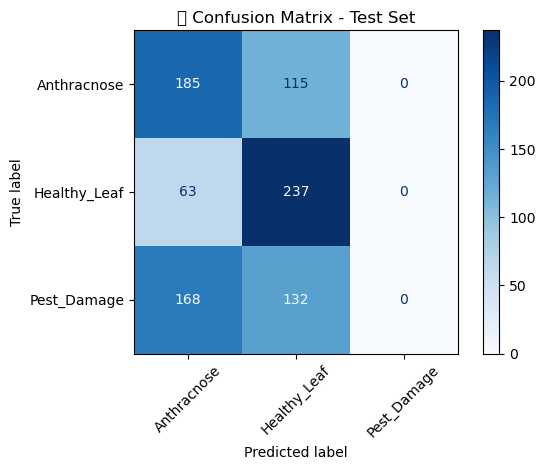

900/900 [==============================] - 12s 13ms/step - loss: 1.1737 - accuracy: 0.4689 - top_2_accuracy: 0.6667
✅ loss: 1.1737
✅ accuracy: 0.4689
✅ top_2_accuracy: 0.6667


In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 🧠 Get ground truth labels and predictions
y_true = []
y_pred = []

# Loop through test_ds
for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.append(np.argmax(preds, axis=1)[0])
    y_true.append(np.argmax(labels.numpy(), axis=1)[0])

# 📊 Evaluation metrics
print("✅ Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 🧾 Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("🧠 Confusion Matrix - Test Set")
plt.grid(False)
plt.tight_layout()
plt.show()

# 🎯 Basic accuracy
results = model.evaluate(test_ds, verbose=1)
for name, value in zip(model.metrics_names, results):
    print(f"✅ {name}: {value:.4f}")



In [29]:
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy

# 🧠 Step 1: Unfreeze the deeper layers of the base model
fine_tune_at = len(base_model.layers) - 30  # Adjust this value as needed

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print(f"✅ Unfroze last {len(base_model.layers) - fine_tune_at} layers out of {len(base_model.layers)} total.")

# ⚙️ Step 2: Re-compile the model with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        TopKCategoricalAccuracy(k=2, name='top_2_accuracy')
    ]
)

# 🔁 Step 3: Resume training with callbacks
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # Can increase if needed
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

# 💾 Step 4: Save fine-tuning history
pd.DataFrame(fine_tune_history.history).to_csv("fine_tuning_history.csv", index=False)
print("📁 Fine-tuning history saved to 'fine_tuning_history.csv'")


✅ Unfroze last 30 layers out of 263 total.
Epoch 1/30
130/132 [============================>.] - ETA: 0s - loss: 0.8134 - accuracy: 0.6365 - top_2_accuracy: 0.8771
Epoch 1: val_loss did not improve from 0.87565
132/132 [==============================] - 7s 27ms/step - loss: 0.8133 - accuracy: 0.6352 - top_2_accuracy: 0.8778 - val_loss: 2.4559 - val_accuracy: 0.3589 - val_top_2_accuracy: 0.7644
Epoch 2/30
129/132 [============================>.] - ETA: 0s - loss: 0.8188 - accuracy: 0.6322 - top_2_accuracy: 0.8828
Epoch 2: val_loss did not improve from 0.87565
132/132 [==============================] - 3s 20ms/step - loss: 0.8190 - accuracy: 0.6328 - top_2_accuracy: 0.8838 - val_loss: 0.9511 - val_accuracy: 0.5400 - val_top_2_accuracy: 0.7567
Epoch 3/30
130/132 [============================>.] - ETA: 0s - loss: 0.8068 - accuracy: 0.6401 - top_2_accuracy: 0.8890
Epoch 3: val_loss did not improve from 0.87565
132/132 [==============================] - 3s 20ms/step - loss: 0.8054 - accuracy

C:\Users\pondt\AppData\Local\Temp\ipykernel_17128\163521636.py:22: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\pondt\anaconda3\envs\efficientnet\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


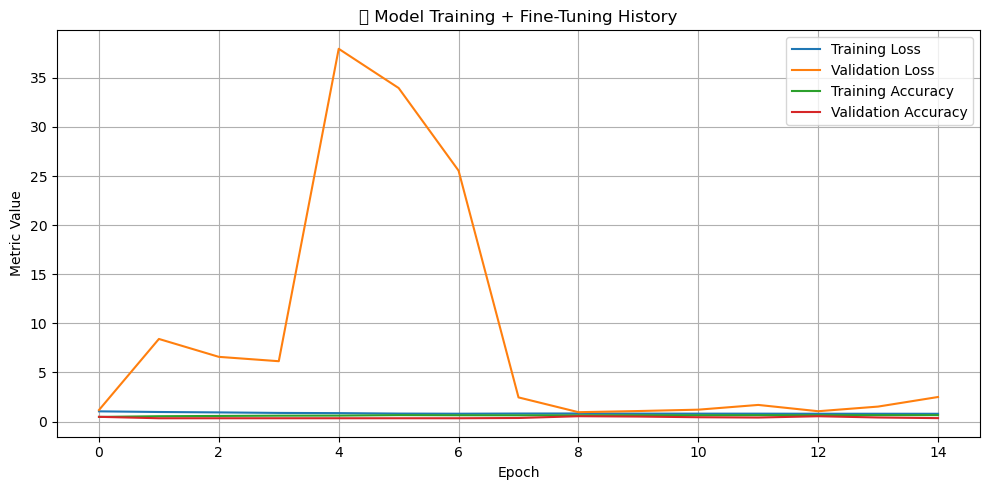

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load histories
train_history = pd.read_csv("training_history_mobilenetv3.csv")
fine_history = pd.read_csv("fine_tuning_history.csv")

# Combine them
full_history = pd.concat([train_history, fine_history], ignore_index=True)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(full_history["loss"], label="Training Loss")
plt.plot(full_history["val_loss"], label="Validation Loss")
plt.plot(full_history["accuracy"], label="Training Accuracy")
plt.plot(full_history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("📊 Model Training + Fine-Tuning History")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
# Count trainable parameters
print(f"Trainable params: {np.sum([np.prod(v.shape) for v in model.trainable_weights])}")
print(f"Non-trainable params: {np.sum([np.prod(v.shape) for v in model.non_trainable_weights])}")


Trainable params: 1023219
Non-trainable params: 2043600


In [32]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 5550495601937790102
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14035189760
locality {
  bus_id: 1
  links {
  }
}
incarnation: 15182218085236961703
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9"
xla_global_id: 416903419
]


In [33]:
fine_tune_at = len(base_model.layers) - 120  # Or more layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=2)
    ]
)


In [34]:
loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)


Epoch 1/10
132/132 [==============================] - ETA: 0s - loss: 0.8225 - accuracy: 0.6311 - top_k_categorical_accuracy: 0.8781
Epoch 1: val_loss did not improve from 0.87565
132/132 [==============================] - 8s 34ms/step - loss: 0.8225 - accuracy: 0.6311 - top_k_categorical_accuracy: 0.8781 - val_loss: 1.8583 - val_accuracy: 0.4367 - val_top_k_categorical_accuracy: 0.6667
Epoch 2/10
130/132 [============================>.] - ETA: 0s - loss: 0.8059 - accuracy: 0.6375 - top_k_categorical_accuracy: 0.8759
Epoch 2: val_loss did not improve from 0.87565
132/132 [==============================] - 3s 26ms/step - loss: 0.8062 - accuracy: 0.6371 - top_k_categorical_accuracy: 0.8766 - val_loss: 2.5058 - val_accuracy: 0.3989 - val_top_k_categorical_accuracy: 0.6667
Epoch 3/10
130/132 [============================>.] - ETA: 0s - loss: 0.8004 - accuracy: 0.6554 - top_k_categorical_accuracy: 0.8888
Epoch 3: val_loss did not improve from 0.87565
132/132 [==============================]